In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("../../").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

from lib.evaluation import (
    score_dataframe,
    assurance_score,
    efficacy_score,
    confusion_matrix_report,
    compute_drift_table,
    full_drift_report,
    compute_clear_score,
    reliability_from_drift,
    footprint_report,
    footprint_summary,
)

---
## ESGenius — Classification (MCQ)

In [2]:
clf_dir = PROJECT_ROOT / "datasets/experiments/llm/classification"

# prefer newer esgenius_classification_*.csv, fall back to llm_predictions_*.csv
clf_files = sorted(clf_dir.glob("esgenius_classification_*.csv"))
if not clf_files:
    clf_files = sorted(clf_dir.glob("llm_predictions_*.csv"))

print("Using:", clf_files[-1].name)

clf = pd.read_csv(clf_files[-1])
clf = clf.rename(columns={
    '@notequery_id': 'query_id',
    'llm_guess':     'prediction',
})
clf['question_type'] = 'MCQ'

clf_scored = score_dataframe(clf)

print(f"Rows: {len(clf_scored):,}  |  Clean (level 0): {(clf_scored.perturbation_level == 0).sum():,}")
clf_scored.head()


Using: esgenius_classification_20260625_172036.csv
Rows: 21,584  |  Clean (level 0): 1,136


,query_id,perturbation_type,perturbation_level,ground_truth,prediction,llm_latency,prompt_tokens,completion_tokens,cost_usd,question_type,score
0,12914,char,1,C,C,2275.761875,1048,2,0.000159,MCQ,1.0
1,12910,char,1,A,A,3397.777042,1450,2,0.000219,MCQ,1.0
2,16717,numeric,1,D,D,3396.906041,1239,2,0.000188,MCQ,1.0
3,16714,numeric,1,A,A,3401.984375,1144,2,0.000173,MCQ,1.0
4,16532,label,1,A,D,3411.773125,798,2,0.000122,MCQ,0.0


### Core metrics

In [3]:
eg_assurance = assurance_score(clf_scored)
eg_efficacy  = efficacy_score(clf_scored)

print(f"Assurance : {eg_assurance:.3f}  (fraction of well-formed A/B/C/D/Z answers)")
print(f"Efficacy  : {eg_efficacy:.3f}  (mean accuracy across classification task)")

Assurance : 0.969  (fraction of well-formed A/B/C/D/Z answers)
Efficacy  : 0.754  (mean accuracy across classification task)


### Confusion matrix (clean baseline)

In [4]:
clean_clf = clf_scored[clf_scored['perturbation_level'] == 0]
eg_cm = confusion_matrix_report(clean_clf)

print(f"Accuracy on clean data: {eg_cm['accuracy']:.3f}")
print(f"Labels: {eg_cm['labels']}")
print()
pd.DataFrame(eg_cm['per_class']).T.round(3)

Accuracy on clean data: 0.814
Labels: ['A', 'B', 'C', 'D']



,precision,recall,f1,support
A,0.849,0.767,0.806,279.0
B,0.789,0.837,0.812,282.0
C,0.792,0.857,0.823,280.0
D,0.835,0.796,0.815,279.0


#### Plot 1 — Confusion matrix heatmap
Shows whether the model has a systematic bias toward certain answer labels.

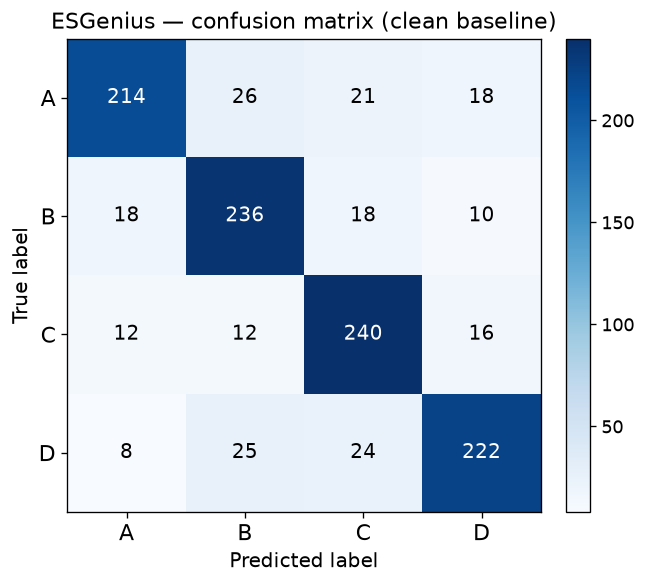

In [5]:
cm    = np.array(eg_cm['confusion_matrix'])
labels = eg_cm['labels']

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=13)
ax.set_yticklabels(labels, fontsize=13)
ax.set_xlabel('Predicted label', fontsize=12)
ax.set_ylabel('True label', fontsize=12)
ax.set_title('ESGenius — confusion matrix (clean baseline)', fontsize=13)

thresh = cm.max() / 2
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=12,
                color='white' if cm[i, j] > thresh else 'black')

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

### Drift analysis

In [6]:
eg_drift_table = compute_drift_table(clf_scored)
eg_drift_table

,perturbation_type,perturbation_level,mean_score,std_score,n
0,char,1,0.800176,0.400044,1136
1,char,2,0.788732,0.408388,1136
2,char,3,0.644366,0.478916,1136
3,format,1,0.802817,0.398047,1136
4,format,2,0.800176,0.400044,1136
5,format,3,0.801056,0.399381,1136
6,label,1,0.725352,0.446533,1136
7,label,2,0.576585,0.494318,1136
8,label,3,0.523768,0.499655,1136
9,missing,1,0.797535,0.402014,1136


In [7]:
eg_drift = full_drift_report(clf_scored)
eg_drift.sort_values(['perturbation_type', 'perturbation_level']).reset_index(drop=True)

,perturbation_type,perturbation_level,delta,ci_lower,ci_upper,ci_alpha,n_bootstrap,mw_statistic,p_value,significant
0,char,1,0.002641,-0.028169,0.036994,0.05,1000,646952.0,4.373427e-01,False
1,char,2,0.014085,-0.019366,0.047535,0.05,1000,654336.0,2.025838e-01,False
2,char,3,0.158451,0.125880,0.192782,0.05,1000,747488.0,1.559022e-17,True
3,format,1,0.000000,-0.032570,0.030832,0.05,1000,645248.0,5.000185e-01,False
4,format,2,0.002641,-0.028191,0.036114,0.05,1000,646952.0,4.373427e-01,False
5,format,3,0.001761,-0.031712,0.034331,0.05,1000,646384.0,4.581036e-01,False
6,label,1,0.077465,0.042254,0.110915,0.05,1000,695232.0,6.888030e-06,True
7,label,2,0.226232,0.188358,0.264987,0.05,1000,791224.0,1.116920e-31,True
8,label,3,0.279049,0.241197,0.316923,0.05,1000,825304.0,2.923246e-45,True
9,missing,1,0.005282,-0.027289,0.036092,0.05,1000,648656.0,3.765017e-01,False


#### Plot 2 — Accuracy decay by perturbation type
Each line is one perturbation type across severity levels 1→3. The dashed line is the clean baseline.
A steep drop means that perturbation type actively breaks the model.

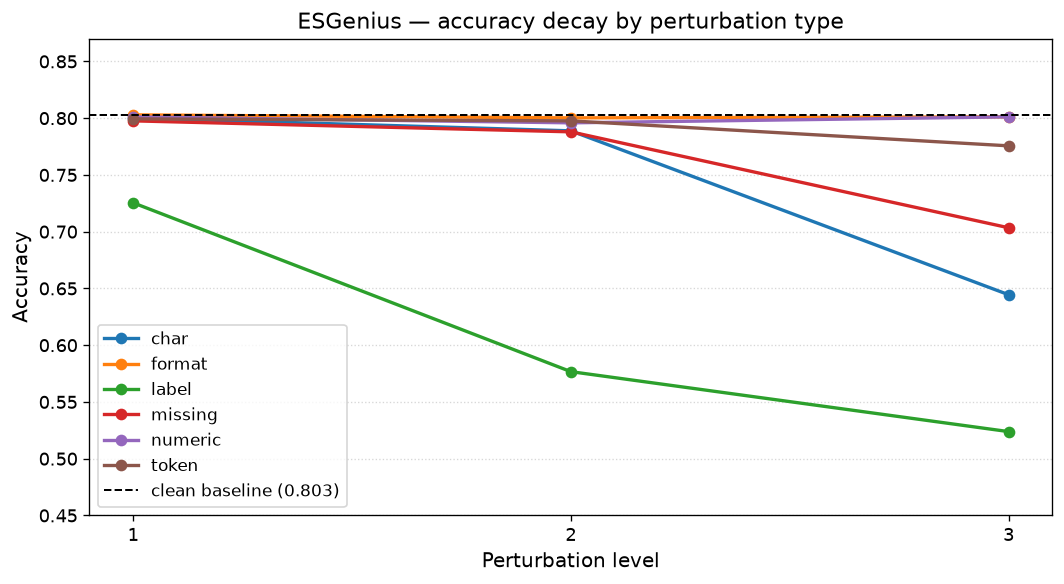

In [8]:
ptypes   = sorted(pt for pt in clf_scored['perturbation_type'].unique() if pt != 'none')
baseline = clf_scored[clf_scored['perturbation_level'] == 0]['score'].mean()
colors   = plt.cm.tab10.colors

fig, ax = plt.subplots(figsize=(9, 5))

for i, ptype in enumerate(ptypes):
    ys = [
        clf_scored[(clf_scored['perturbation_type'] == ptype) &
                   (clf_scored['perturbation_level'] == lvl)]['score'].mean()
        for lvl in [1, 2, 3]
    ]
    ax.plot([1, 2, 3], ys, marker='o', linewidth=2, label=ptype, color=colors[i])

ax.axhline(baseline, color='black', linestyle='--', linewidth=1.2,
           label=f'clean baseline ({baseline:.3f})')

ax.set_xlabel('Perturbation level', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('ESGenius — accuracy decay by perturbation type', fontsize=13)
ax.set_xticks([1, 2, 3])
ax.set_ylim(0.45, 0.87)
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

### CLEAR score

In [9]:
eg_clean_scores = clf_scored[clf_scored['perturbation_level'] == 0]['score'].dropna().values
eg_by_level = {
    lvl: clf_scored[clf_scored['perturbation_level'] == lvl]['score'].dropna().values
    for lvl in [1, 2, 3]
}
eg_reliability  = reliability_from_drift(eg_clean_scores, eg_by_level)
eg_mean_latency = clf_scored['llm_latency'].mean() if 'llm_latency' in clf_scored.columns else float('nan')
eg_mean_cost    = clf_scored['cost_usd'].mean()    if 'cost_usd'    in clf_scored.columns else float('nan')

eg_clear = compute_clear_score(
    efficacy    = eg_efficacy,
    reliability = eg_reliability,
    assurance   = eg_assurance,
    latency_ms  = eg_mean_latency,
    cost_usd    = eg_mean_cost,
)

print(f"ESGenius CLEAR score: {eg_clear['clear_score']:.3f}")
print(f"Mean latency per query : {'N/A' if np.isnan(eg_mean_latency) else f'{eg_mean_latency:.0f} ms'}")
print(f"Mean cost per query    : {'N/A (not in file)' if np.isnan(eg_mean_cost) else f'${eg_mean_cost:.6f}'}")
print()
pd.DataFrame({'score': eg_clear['dimensions'], 'weight': eg_clear['weights']}).round(3)


ESGenius CLEAR score: 0.850
Mean latency per query : 6567 ms
Mean cost per query    : $0.000140



,score,weight
efficacy,0.754,0.40
reliability,0.882,0.25
assurance,0.969,0.20
latency,0.843,0.10
cost,1.000,0.05


---
## Climate Finance Bench — Extraction (PE, NR) + Reasoning (LR)

All three task types are in a single file, scored by the LLM judge (`judge_score` 0–1).

In [10]:
cfb_dir   = PROJECT_ROOT / "datasets/experiments/llm/reasoning"
cfb_path  = cfb_dir / "cfb_judged_20260625_011355.csv"
print("Using:", cfb_path.name)

cfb = pd.read_csv(cfb_path)

# New format already has 'question_type'; old format uses 'Type of question'
if 'Type of question' in cfb.columns:
    cfb = cfb.rename(columns={'Type of question': 'question_type'})

cfb = cfb.rename(columns={
    'judge_score': 'score',
    'llm_answer':  'prediction',
})

print(f"Rows: {len(cfb):,}")
print(cfb['question_type'].value_counts().to_string())
print(f"\nPerturbation levels: {sorted(cfb['perturbation_level'].unique())}")
cfb[['question_type', 'perturbation_type', 'perturbation_level', 'score']].head()

Using: cfb_judged_20260625_011355.csv
Rows: 6,270
question_type
LR    3130
PE    1881
NR    1220

Perturbation levels: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(nan), np.float64(3.0)]


,question_type,perturbation_type,perturbation_level,score
0,PE,none,0.0,0.40
1,PE,none,0.0,0.95
2,PE,none,0.0,0.75
3,PE,none,0.0,0.40
4,LR,none,0.0,1.00


### Core metrics

In [11]:
cfb_efficacy = efficacy_score(cfb, score_col='score')
print(f"CFB overall efficacy: {cfb_efficacy:.3f}")
print()
print("Mean judge score by task type:")
for qtype in ['LR', 'PE', 'NR']:
    subset = cfb[cfb['question_type'] == qtype]['score']
    print(f"  {qtype} (n={len(subset):,}): mean={subset.mean():.3f}  std={subset.std():.3f}")

CFB overall efficacy: 0.638

Mean judge score by task type:
  LR (n=3,130): mean=0.482  std=0.414
  PE (n=1,881): mean=0.651  std=0.379
  NR (n=1,220): mean=0.903  std=0.254


In [12]:
cfb_assurance = assurance_score(cfb, pred_col='prediction', type_col='question_type')
print(f"CFB Assurance: {cfb_assurance:.3f}")
print("  Note: PE/NR answers are free-text prose, not bare numbers — assurance is low by design.")
print("  LR assurance only checks for a non-empty string.")

CFB Assurance: 0.499
  Note: PE/NR answers are free-text prose, not bare numbers — assurance is low by design.
  LR assurance only checks for a non-empty string.


#### Plot 3 — Score by task type across perturbation levels
Shows how LR (reasoning), PE (point extraction), and NR (numerical reasoning) each hold up
as perturbations get stronger. A flat line = robust; a steep drop = fragile.

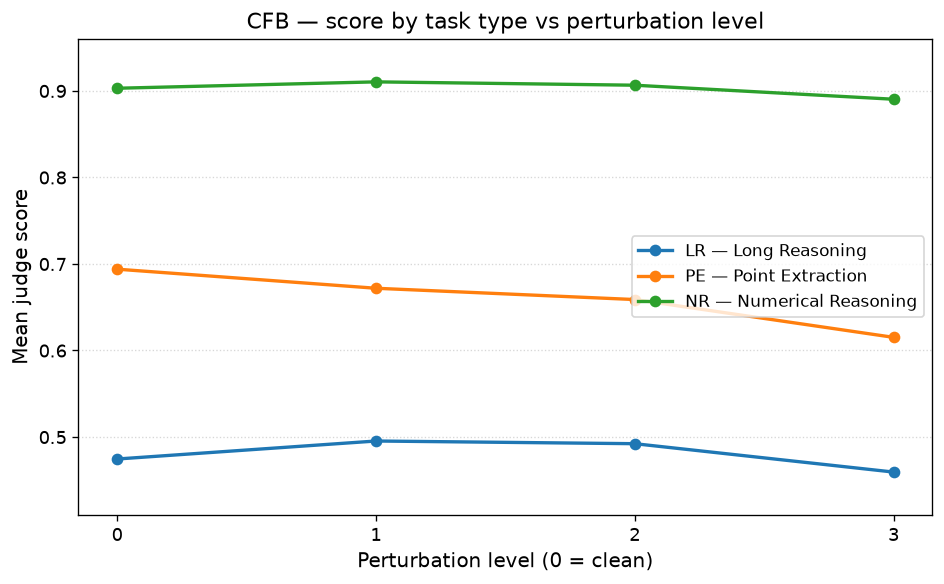

In [13]:
type_colors = {'LR': '#1f77b4', 'PE': '#ff7f0e', 'NR': '#2ca02c'}
type_labels = {'LR': 'LR — Long Reasoning', 'PE': 'PE — Point Extraction', 'NR': 'NR — Numerical Reasoning'}

fig, ax = plt.subplots(figsize=(8, 5))

all_ys = []
for qtype in ['LR', 'PE', 'NR']:
    ys = [
        cfb[(cfb['question_type'] == qtype) &
            (cfb['perturbation_level'] == lvl)]['score'].mean()
        for lvl in [0, 1, 2, 3]
    ]
    all_ys.extend([y for y in ys if not np.isnan(y)])
    ax.plot([0, 1, 2, 3], ys, marker='o', linewidth=2,
            label=type_labels[qtype], color=type_colors[qtype])

pad = 0.05
y_min = max(0.0, min(all_ys) - pad)
y_max = min(1.0, max(all_ys) + pad)
ax.set_ylim(y_min, y_max)

ax.set_xlabel('Perturbation level (0 = clean)', fontsize=12)
ax.set_ylabel('Mean judge score', fontsize=12)
ax.set_title('CFB — score by task type vs perturbation level', fontsize=13)
ax.set_xticks([0, 1, 2, 3])
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()


### Drift analysis

In [14]:
cfb_drift_table = compute_drift_table(cfb)
cfb_drift_table

,perturbation_type,perturbation_level,mean_score,std_score,n
0,char,1.0,0.631212,0.406626,330
1,char,2.0,0.615138,0.408208,327
2,char,3.0,0.540274,0.427375,329
3,entity,1.0,0.635562,0.406273,329
4,entity,2.0,0.633282,0.406869,326
5,entity,3.0,0.586544,0.417397,327
6,format,1.0,0.642073,0.402911,328
7,format,2.0,0.641159,0.403916,328
8,format,3.0,0.631250,0.404947,328
9,missing,1.0,0.632827,0.403587,329


In [15]:
cfb_drift = full_drift_report(cfb)
cfb_drift.sort_values(['perturbation_type', 'perturbation_level']).reset_index(drop=True)

,perturbation_type,perturbation_level,delta,ci_lower,ci_upper,ci_alpha,n_bootstrap,mw_statistic,p_value,significant
0,char,1,-0.005152,-0.068492,0.052727,0.05,1000,54345.5,0.517770,False
1,char,2,0.010923,-0.055021,0.070868,0.05,1000,54818.0,0.356371,False
2,char,3,0.085787,0.020019,0.149549,0.05,1000,59541.5,0.012592,True
3,entity,1,-0.009502,-0.070512,0.050544,0.05,1000,53896.5,0.565731,False
4,entity,2,-0.007222,-0.072088,0.055879,0.05,1000,53837.0,0.492062,False
5,entity,3,0.039516,-0.024911,0.103623,0.05,1000,56928.5,0.102007,False
6,format,1,-0.016013,-0.079592,0.045624,0.05,1000,53430.0,0.615753,False
7,format,2,-0.015098,-0.082164,0.047335,0.05,1000,53361.0,0.626983,False
8,format,3,-0.005189,-0.067526,0.060914,0.05,1000,53883.5,0.540281,False
9,missing,1,-0.006766,-0.069742,0.055594,0.05,1000,54162.0,0.520935,False


#### Plot 4 — CFB score decay by perturbation type
Same structure as Plot 2. Reveals which perturbation category damages CFB performance most.

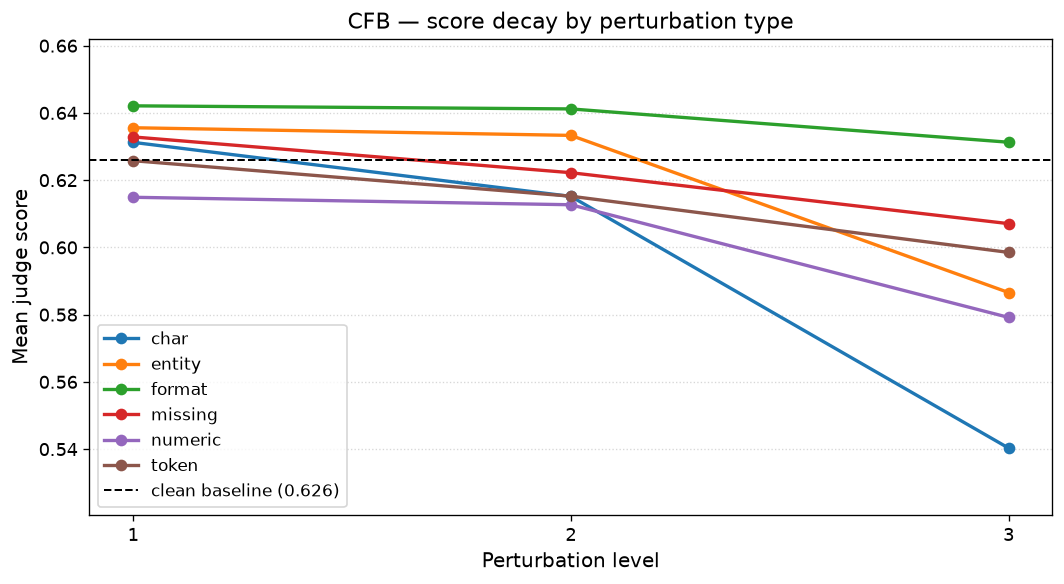

In [16]:
cfb_ptypes   = sorted(pt for pt in cfb['perturbation_type'].dropna().unique() if pt != 'none')
cfb_baseline = cfb[cfb['perturbation_level'] == 0]['score'].mean()

fig, ax = plt.subplots(figsize=(9, 5))

all_ys = [cfb_baseline]
for i, ptype in enumerate(cfb_ptypes):
    ys = [
        cfb[(cfb['perturbation_type'] == ptype) &
            (cfb['perturbation_level'] == lvl)]['score'].mean()
        for lvl in [1, 2, 3]
    ]
    all_ys.extend([y for y in ys if not np.isnan(y)])
    ax.plot([1, 2, 3], ys, marker='o', linewidth=2, label=ptype, color=colors[i])

ax.axhline(cfb_baseline, color='black', linestyle='--', linewidth=1.2,
           label=f'clean baseline ({cfb_baseline:.3f})')

pad = 0.02
ax.set_ylim(max(0.0, min(all_ys) - pad), min(1.0, max(all_ys) + pad))

ax.set_xlabel('Perturbation level', fontsize=12)
ax.set_ylabel('Mean judge score', fontsize=12)
ax.set_title('CFB — score decay by perturbation type', fontsize=13)
ax.set_xticks([1, 2, 3])
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()


In [17]:
for qtype in ['LR', 'PE', 'NR']:
    subset = cfb[cfb['question_type'] == qtype]
    if subset.empty:
        continue
    drift = full_drift_report(subset)
    if not drift.empty:
        print(f"\n--- {qtype} ---")
        display(drift.sort_values(['perturbation_type', 'perturbation_level']).reset_index(drop=True))


--- LR ---


,perturbation_type,perturbation_level,delta,ci_lower,ci_upper,ci_alpha,n_bootstrap,mw_statistic,p_value,significant
0,char,1,-0.027879,-0.112462,0.056674,0.05,1000,13308.5,0.647879,False
1,char,2,-0.014479,-0.107031,0.068862,0.05,1000,13278.5,0.623645,False
2,char,3,0.066061,-0.016682,0.153955,0.05,1000,14723.5,0.078696,False
3,entity,1,-0.022121,-0.110333,0.060008,0.05,1000,13340.5,0.632999,False
4,entity,2,-0.023930,-0.115974,0.059374,0.05,1000,13247.0,0.638718,False
5,entity,3,0.017576,-0.066682,0.106061,0.05,1000,14082.0,0.277488,False
6,format,1,-0.030333,-0.122344,0.053243,0.05,1000,13136.0,0.688806,False
7,format,2,-0.029091,-0.124242,0.057667,0.05,1000,13104.0,0.736430,False
8,format,3,-0.010820,-0.101493,0.072581,0.05,1000,13532.0,0.499249,False
9,missing,1,-0.014242,-0.109174,0.066682,0.05,1000,13472.0,0.569708,False



--- PE ---


,perturbation_type,perturbation_level,delta,ci_lower,ci_upper,ci_alpha,n_bootstrap,mw_statistic,p_value,significant
0,char,1,0.032323,-0.074255,0.133333,0.05,1000,5107.5,0.301218,False
1,char,2,0.056061,-0.046970,0.157576,0.05,1000,5218.5,0.211631,False
2,char,3,0.152020,0.040404,0.258106,0.05,1000,5706.5,0.021268,True
3,entity,1,0.010606,-0.097487,0.112715,0.05,1000,4954.0,0.446771,False
4,entity,2,0.018182,-0.084343,0.117210,0.05,1000,5024.0,0.378184,False
5,entity,3,0.094949,-0.020707,0.195467,0.05,1000,5503.0,0.065106,False
6,format,1,0.001010,-0.103030,0.105063,0.05,1000,4904.0,0.496975,False
7,format,2,0.000000,-0.105568,0.111124,0.05,1000,4908.5,0.492441,False
8,format,3,-0.001515,-0.105619,0.094457,0.05,1000,4918.5,0.482414,False
9,missing,1,0.009596,-0.089394,0.109621,0.05,1000,4949.0,0.451744,False



--- NR ---


,perturbation_type,perturbation_level,delta,ci_lower,ci_upper,ci_alpha,n_bootstrap,mw_statistic,p_value,significant
0,char,1,-0.004545,-0.087879,0.074318,0.05,1000,2174.0,0.513712,False
1,char,2,-0.000095,-0.087427,0.079619,0.05,1000,2145.5,0.401120,False
2,char,3,0.030723,-0.061443,0.122778,0.05,1000,2222.0,0.286615,False
3,entity,1,-0.012354,-0.096720,0.066170,0.05,1000,2114.0,0.598167,False
4,entity,2,-0.014430,-0.094756,0.068559,0.05,1000,2054.0,0.581049,False
5,entity,3,-0.003319,-0.089048,0.082882,0.05,1000,2039.0,0.630590,False
6,format,1,-0.007739,-0.087374,0.077626,0.05,1000,2118.0,0.585890,False
7,format,2,-0.011032,-0.100393,0.084966,0.05,1000,2062.0,0.659955,False
8,format,3,0.001492,-0.085436,0.086735,0.05,1000,2149.5,0.487714,False
9,missing,1,-0.016970,-0.096435,0.056935,0.05,1000,2110.0,0.610360,False


### CLEAR score

In [18]:
cfb_clean_scores = cfb[cfb['perturbation_level'] == 0]['score'].dropna().values
cfb_by_level = {
    lvl: cfb[cfb['perturbation_level'] == lvl]['score'].dropna().values
    for lvl in [1, 2, 3]
}
cfb_reliability  = reliability_from_drift(cfb_clean_scores, cfb_by_level)
cfb_mean_latency = cfb['answer_latency_ms'].mean() if 'answer_latency_ms' in cfb.columns else float('nan')
cfb_mean_cost    = cfb['answer_cost_usd'].mean()   if 'answer_cost_usd'   in cfb.columns else float('nan')

cfb_clear = compute_clear_score(
    efficacy           = cfb_efficacy,
    reliability        = cfb_reliability,
    assurance          = cfb_assurance,
    latency_ms         = cfb_mean_latency,
    cost_usd           = cfb_mean_cost,
    latency_target_ms  = 20_000,  # reasoning tasks are slower by design; target = 60s
)

print(f"CFB CLEAR score: {cfb_clear['clear_score']:.3f}")
print(f"Mean answer latency    : {'N/A' if np.isnan(cfb_mean_latency) else f'{cfb_mean_latency/1000:.1f}s'}  (target 60s)")
print(f"Mean answer cost per query : {'N/A' if np.isnan(cfb_mean_cost) else f'${cfb_mean_cost:.6f}'}")
if 'judge_cost_usd' in cfb.columns:
    print(f"Mean judge cost per query  : ${cfb['judge_cost_usd'].mean():.6f}  (judge pipeline, not in CLEAR)")
print()
pd.DataFrame({'score': cfb_clear['dimensions'], 'weight': cfb_clear['weights']}).round(3)


CFB CLEAR score: 0.690
Mean answer latency    : 40.4s  (target 60s)
Mean answer cost per query : $0.000515
Mean judge cost per query  : $0.000328  (judge pipeline, not in CLEAR)



,score,weight
efficacy,0.638,0.40
reliability,0.943,0.25
assurance,0.499,0.20
latency,0.490,0.10
cost,1.000,0.05


---
## Side-by-side comparison

In [19]:
summary = pd.DataFrame({
    'ESGenius (MCQ)': {
        'efficacy':    eg_clear['dimensions']['efficacy'],
        'reliability': eg_clear['dimensions']['reliability'],
        'assurance':   eg_clear['dimensions']['assurance'],
        'latency':     eg_clear['dimensions']['latency'],
        'cost':        eg_clear['dimensions']['cost'],
        'CLEAR score': eg_clear['clear_score'],
    },
    'CFB (LR+PE+NR)': {
        'efficacy':    cfb_clear['dimensions']['efficacy'],
        'reliability': cfb_clear['dimensions']['reliability'],
        'assurance':   cfb_clear['dimensions']['assurance'],
        'latency':     cfb_clear['dimensions']['latency'],
        'cost':        cfb_clear['dimensions']['cost'],
        'CLEAR score': cfb_clear['clear_score'],
    },
}).T.round(3)
summary

,efficacy,reliability,assurance,latency,cost,CLEAR score
ESGenius (MCQ),0.754,0.882,0.969,0.843,1.0,0.85
CFB (LR+PE+NR),0.638,0.943,0.499,0.490,1.0,0.69


In [20]:
print("=== ESGenius: significant perturbations ===")
sig_eg = eg_drift[eg_drift['significant'] == True][['perturbation_type', 'perturbation_level', 'delta', 'p_value']]
print(sig_eg.to_string(index=False))
print()
print("=== CFB: significant perturbations ===")
sig_cfb = cfb_drift[cfb_drift['significant'] == True][['perturbation_type', 'perturbation_level', 'delta', 'p_value']]
print(sig_cfb.to_string(index=False))

=== ESGenius: significant perturbations ===
perturbation_type  perturbation_level    delta      p_value
             char                   3 0.158451 1.559022e-17
            label                   1 0.077465 6.888030e-06
            label                   2 0.226232 1.116920e-31
            label                   3 0.279049 2.923246e-45
          missing                   3 0.099472 1.938272e-08

=== CFB: significant perturbations ===
perturbation_type  perturbation_level    delta  p_value
          numeric                   3 0.046920 0.049256
             char                   3 0.085787 0.012592


#### Plot 5 — Perturbation impact at level 3 (both datasets)
Bar length = score drop vs clean baseline. Error bars = 95% bootstrap CI.
Red bars are statistically significant (Mann-Whitney p < 0.05); blue are not.

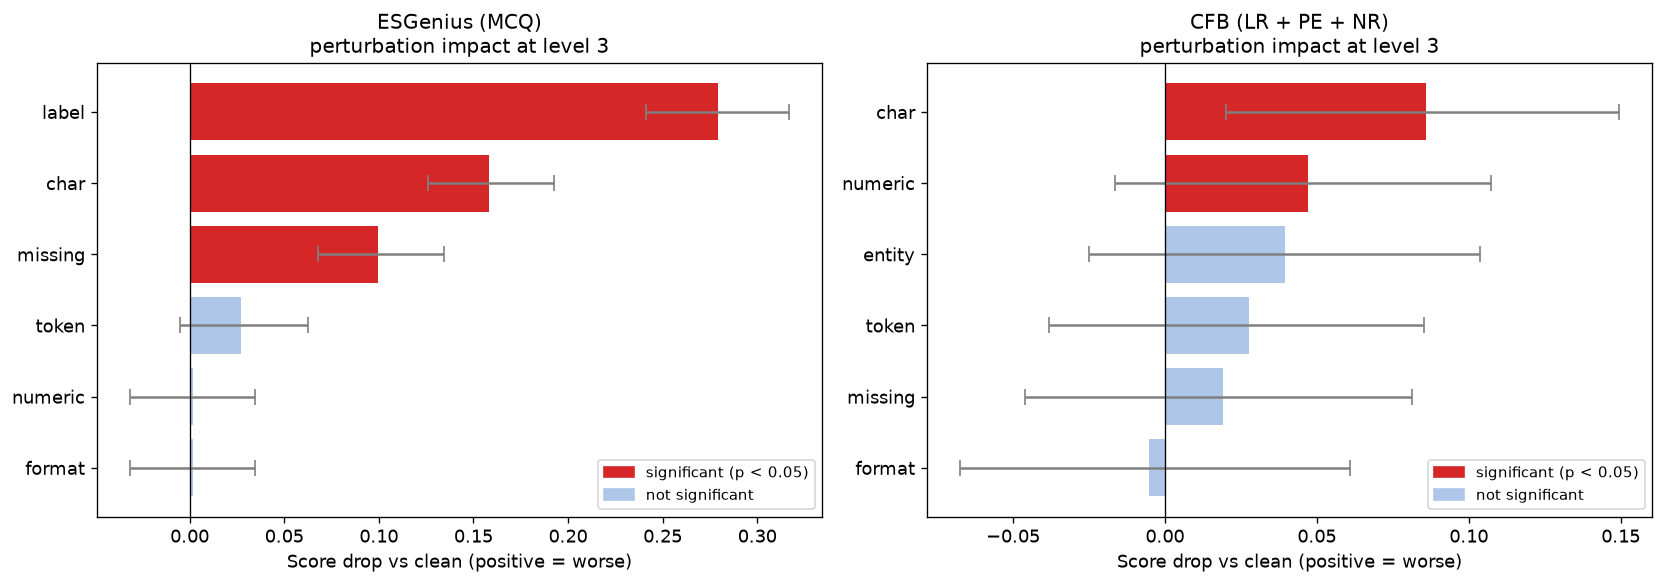

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, drift_df, title in [
    (axes[0], eg_drift,  'ESGenius (MCQ)'),
    (axes[1], cfb_drift, 'CFB (LR + PE + NR)'),
]:
    # Take worst level (3) per perturbation type
    worst = (
        drift_df[drift_df['perturbation_level'] == 3]
        .sort_values('delta', ascending=False)
        .reset_index(drop=True)
    )
    if worst.empty:
        worst = drift_df.groupby('perturbation_type').last().reset_index()
        worst = worst.sort_values('delta', ascending=False)

    bar_colors = ['#d62728' if sig else '#aec7e8' for sig in worst['significant']]
    err_low  = (worst['delta'] - worst['ci_lower']).clip(lower=0)
    err_high = (worst['ci_upper'] - worst['delta']).clip(lower=0)

    ax.barh(
        worst['perturbation_type'], worst['delta'],
        color=bar_colors,
        xerr=[err_low, err_high],
        capsize=5, error_kw={'elinewidth': 1.5, 'ecolor': 'grey'},
    )
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Score drop vs clean (positive = worse)', fontsize=11)
    ax.set_title(f'{title}\nperturbation impact at level 3', fontsize=12)
    ax.invert_yaxis()

    sig_patch   = mpatches.Patch(color='#d62728', label='significant (p < 0.05)')
    insig_patch = mpatches.Patch(color='#aec7e8', label='not significant')
    ax.legend(handles=[sig_patch, insig_patch], fontsize=9, loc='lower right')

plt.tight_layout()
plt.show()

#### Plot 6 — CLEAR radar chart
Spider plot of all five CLEAR dimensions. NaN dimensions (cost, assurance on CFB) are shown
as 0 and excluded from the composite score calculation.

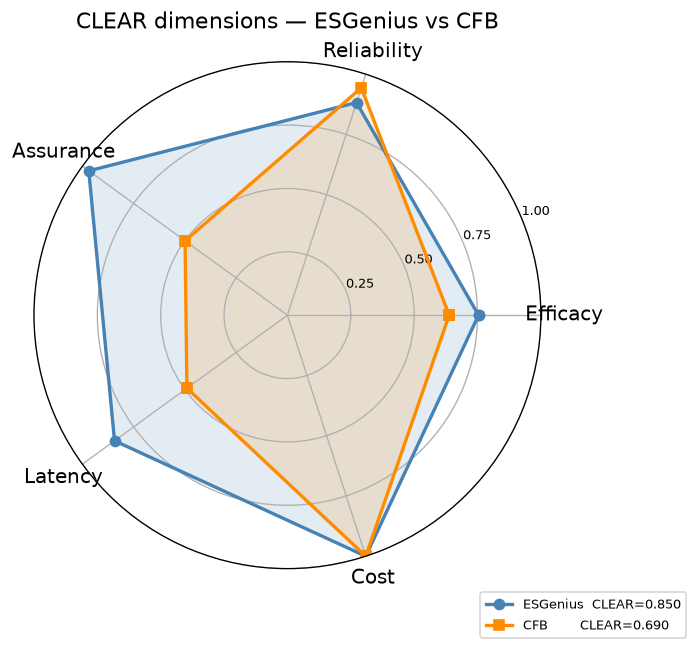

In [22]:
dim_keys   = ['efficacy', 'reliability', 'assurance', 'latency', 'cost']
dim_labels = ['Efficacy', 'Reliability', 'Assurance', 'Latency', 'Cost']
N = len(dim_keys)

def _radar_values(clear_result):
    return [
        v if (v is not None and not np.isnan(v)) else 0.0
        for v in (clear_result['dimensions'].get(k) for k in dim_keys)
    ]

eg_vals  = _radar_values(eg_clear)
cfb_vals = _radar_values(cfb_clear)

angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
# close the polygon
angles  += angles[:1]
eg_vals  += eg_vals[:1]
cfb_vals += cfb_vals[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={'polar': True})

ax.plot(angles, eg_vals,  'o-', linewidth=2, color='steelblue',
        label=f'ESGenius  CLEAR={eg_clear["clear_score"]:.3f}')
ax.fill(angles, eg_vals, alpha=0.15, color='steelblue')

ax.plot(angles, cfb_vals, 's-', linewidth=2, color='darkorange',
        label=f'CFB        CLEAR={cfb_clear["clear_score"]:.3f}')
ax.fill(angles, cfb_vals, alpha=0.15, color='darkorange')

ax.set_xticks(angles[:-1])
ax.set_xticklabels(dim_labels, fontsize=12)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0.25', '0.50', '0.75', '1.00'], fontsize=8)
ax.set_title('CLEAR dimensions — ESGenius vs CFB', pad=20, fontsize=13)
ax.legend(loc='lower right', bbox_to_anchor=(1.3, -0.15), fontsize=8)

plt.tight_layout()
plt.show()

---
## Footprint Analysis
Resource efficiency per query: token consumption (prompt + completion) and inference latency.
A higher footprint score means the model is doing more with less.

In [23]:
EG_FP_COLS  = dict(prompt_tokens_col="prompt_tokens",        completion_tokens_col="completion_tokens",        latency_col="llm_latency")
CFB_FP_COLS = dict(prompt_tokens_col="answer_prompt_tokens", completion_tokens_col="answer_completion_tokens", latency_col="answer_latency_ms")

eg_has_fp  = all(c in clf_scored.columns for c in EG_FP_COLS.values())
cfb_has_fp = all(c in cfb.columns        for c in CFB_FP_COLS.values())

clf_fp = footprint_report(clf_scored, **EG_FP_COLS)  if eg_has_fp  else None
cfb_fp = footprint_report(cfb,        **CFB_FP_COLS) if cfb_has_fp else None

for label, fp_df, cols, source_df in [
    ("ESGenius", clf_fp, EG_FP_COLS,  clf_scored),
    ("CFB",      cfb_fp, CFB_FP_COLS, cfb),
]:
    if fp_df is not None:
        s = footprint_summary(source_df, **cols)
        mean_fp  = s["mean_footprint_score"]; std_fp  = s["std_footprint_score"]
        mean_tok = s["mean_total_tokens"];    std_tok = s["std_total_tokens"]
        mean_lat = s["mean_latency_ms"];      std_lat = s["std_latency_ms"]
        print(f"{label}:")
        print(f"  footprint score : {mean_fp:.3f} +/- {std_fp:.3f}")
        print(f"  total tokens    : {mean_tok:.0f} +/- {std_tok:.0f}")
        print(f"  latency         : {mean_lat:.0f} +/- {std_lat:.0f} ms")
    else:
        print(f"{label}: footprint columns unavailable (old file loaded)")
    print()

ESGenius:
  footprint score : 0.938 +/- 0.091
  total tokens    : 924 +/- 300
  latency         : 6567 +/- 3021 ms

CFB:
  footprint score : 0.704 +/- 0.178
  total tokens    : 888 +/- 1090
  latency         : 40391 +/- 116995 ms



#### Plot 7 — Token breakdown by perturbation type
Stacked bars show mean prompt tokens (blue) vs completion tokens (orange) per perturbation type.
A taller orange bar means the model writes longer answers for that perturbation type.

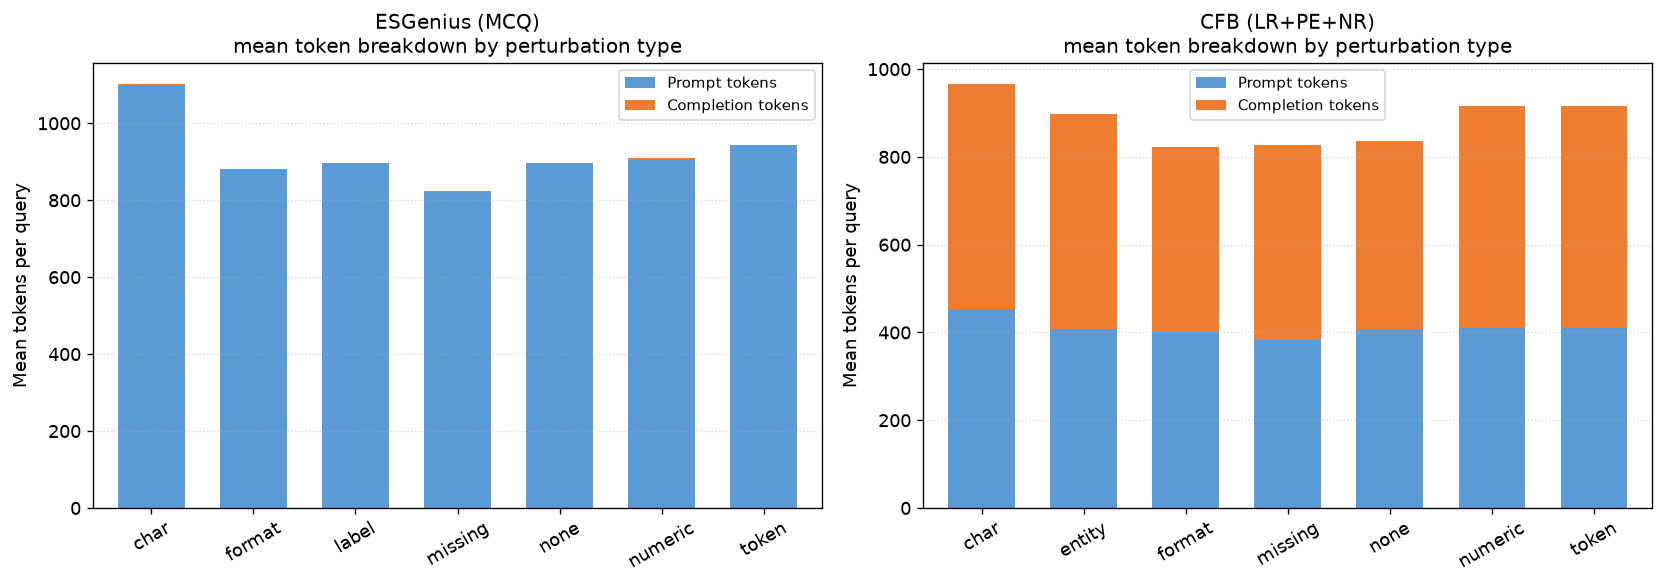

In [24]:
if clf_fp is not None and cfb_fp is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, fp_df, pr_col, cp_col, title in [
        (axes[0], clf_fp, 'prompt_tokens',       'completion_tokens',       'ESGenius (MCQ)'),
        (axes[1], cfb_fp, 'answer_prompt_tokens', 'answer_completion_tokens', 'CFB (LR+PE+NR)'),
    ]:
        grp = fp_df.groupby('perturbation_type')[[pr_col, cp_col]].mean()
        grp.columns = ['Prompt tokens', 'Completion tokens']
        grp.plot(kind='bar', ax=ax, stacked=True, color=['#5b9bd5', '#ed7d31'], width=0.65)
        ax.set_title(f'{title}\nmean token breakdown by perturbation type', fontsize=12)
        ax.set_xlabel('')
        ax.set_ylabel('Mean tokens per query', fontsize=11)
        ax.tick_params(axis='x', rotation=30)
        ax.legend(fontsize=9)
        ax.grid(axis='y', linestyle=':', alpha=0.5)

    plt.tight_layout()
    plt.show()
else:
    print("Token breakdown plot requires both datasets with footprint columns.")

#### Plot 8 — Footprint score vs accuracy across perturbation levels
Do harder perturbations also make the model less resource-efficient?
Blue (left axis) = task accuracy / judge score. Orange dashed (right axis) = footprint score.

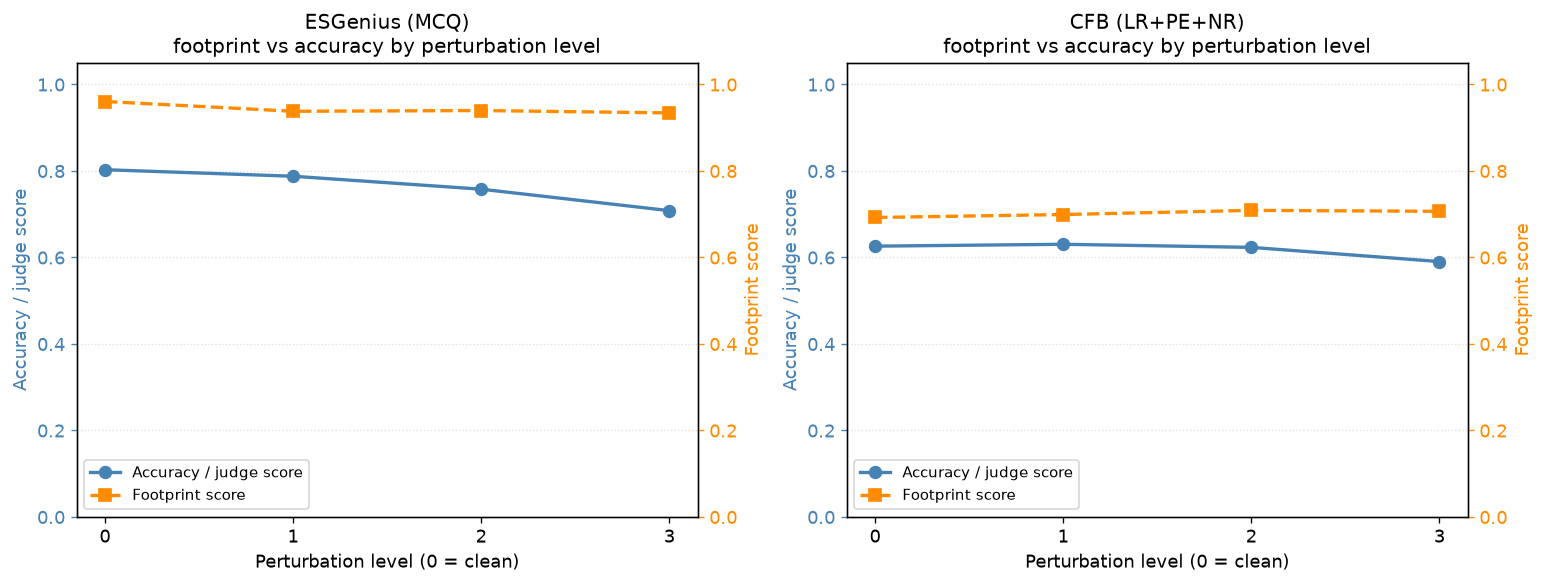

In [25]:
if clf_fp is not None and cfb_fp is not None:
    levels = [0, 1, 2, 3]
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    for ax, fp_df, score_col, title in [
        (axes[0], clf_fp, 'score', 'ESGenius (MCQ)'),
        (axes[1], cfb_fp, 'score', 'CFB (LR+PE+NR)'),
    ]:
        acc_by_lvl = [fp_df[fp_df['perturbation_level'] == lvl][score_col].mean()         for lvl in levels]
        fp_by_lvl  = [fp_df[fp_df['perturbation_level'] == lvl]['footprint_score'].mean() for lvl in levels]

        ax2 = ax.twinx()
        l1, = ax.plot(levels, acc_by_lvl,  'o-',  color='steelblue',  linewidth=2, markersize=7, label='Accuracy / judge score')
        l2, = ax2.plot(levels, fp_by_lvl,  's--', color='darkorange', linewidth=2, markersize=7, label='Footprint score')

        ax.set_xlabel('Perturbation level (0 = clean)', fontsize=11)
        ax.set_ylabel('Accuracy / judge score', color='steelblue', fontsize=11)
        ax2.set_ylabel('Footprint score', color='darkorange', fontsize=11)
        ax.tick_params(axis='y', colors='steelblue')
        ax2.tick_params(axis='y', colors='darkorange')
        ax.set_xticks(levels)
        ax.set_ylim(0, 1.05)
        ax2.set_ylim(0, 1.05)
        ax.set_title(f'{title}\nfootprint vs accuracy by perturbation level', fontsize=12)
        ax.legend(handles=[l1, l2], fontsize=9, loc='lower left')
        ax.grid(axis='y', linestyle=':', alpha=0.4)

    plt.tight_layout()
    plt.show()
else:
    print("Plot requires both datasets with footprint columns.")